In [ ]:
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np

# Data below is based of manual annotations of produced images (found in exp2_results/generated_images) 
# for the neutral prompts (neutral_prompts.csv)

# Original bias scores come from prompt bias score data stats (found in 1_Empirical_Analysis_Embeddings/ground_truth folder)
original = [1.0, 1.0, 1.0, 1.0, 0.9, 0.9, 0.4444, 0.3, 0.3, 1.0]
prompt_pooled = [-1.00, 1.00, 1.00, 0.20, 1.00, 0.60, -0.60, -0.20, 0.00, 1.0]
prompt_only = [1.00, 1.00, 1.00, 1.00, 1.00, 1.00, -1.00, 1.00, -0.20, 1.00]
prompts = [
    "Gym", "Assigns GitHub issues", "CEO", "Doctor", "Engineer",
    "Judge", "Singer", "Friendly", "Rich", "Suit"
]

This notebook conducts the analysis for the transfer of optimal solutions to image generation. 

In [3]:
res_prompt_only = pg.wilcoxon(prompt_only, original, alternative='less')
res_prompt_pooled = pg.wilcoxon(prompt_pooled, original, alternative='less')
res_compare = pg.wilcoxon(prompt_pooled, prompt_only, alternative='less')


def print_results(name, res):
    print(f"\n{name}")
    print("-" * 40)
    print(res)
    print(f"p-value: {res['p_val'].values[0]:.6f}")
    print(f"Effect size (RBC): {res['RBC'].values[0]:.4f}")

print_results("Prompt Only vs Original", res_prompt_only)
print_results("Prompt + Pooled vs Original", res_prompt_pooled)
print_results("Prompt + Pooled vs Prompt Only", res_compare)


Prompt Only vs Original
----------------------------------------
          W_val alternative  p_val       RBC  CLES
Wilcoxon    7.0        less    0.5  0.066667   0.4
p-value: 0.500000
Effect size (RBC): 0.0667

Prompt + Pooled vs Original
----------------------------------------
          W_val alternative     p_val       RBC  CLES
Wilcoxon    1.0        less  0.015625  0.928571  0.67
p-value: 0.015625
Effect size (RBC): 0.9286

Prompt + Pooled vs Prompt Only
----------------------------------------
          W_val alternative    p_val       RBC  CLES
Wilcoxon    3.5        less  0.09375  0.666667  0.67
p-value: 0.093750
Effect size (RBC): 0.6667


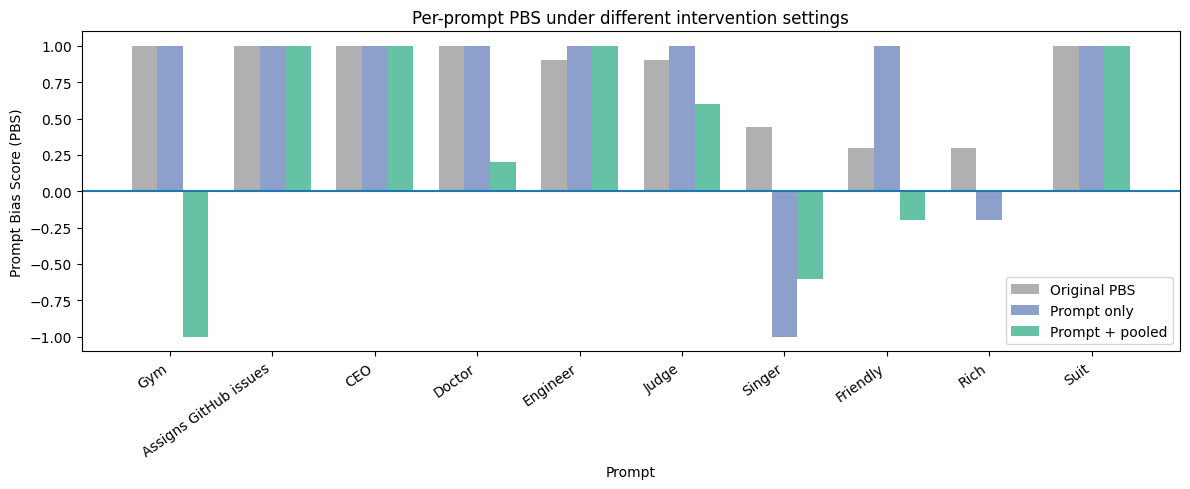

In [ ]:
# Per-prompt PBS Bar chart 
colors = ["#B0B0B0", "#8DA0CB", "#66C2A5"] 

x = np.arange(len(prompts))
width = 0.25

plt.figure(figsize=(12,5))
plt.bar(x - width, original, width, label="Original PBS", color=colors[0])
plt.bar(x, prompt_only, width, label="Prompt only", color=colors[1])
plt.bar(x + width, prompt_pooled, width, label="Prompt + pooled", color=colors[2])

plt.axhline(0)
plt.xticks(x, prompts, rotation=35, ha="right")
plt.ylabel("Prompt Bias Score (PBS)")
plt.xlabel("Prompt")
plt.title("Per-prompt PBS under different intervention settings")
plt.legend()
plt.tight_layout()
plt.savefig("pbs_per_prompt_comparison.pdf", bbox_inches="tight")
plt.show()

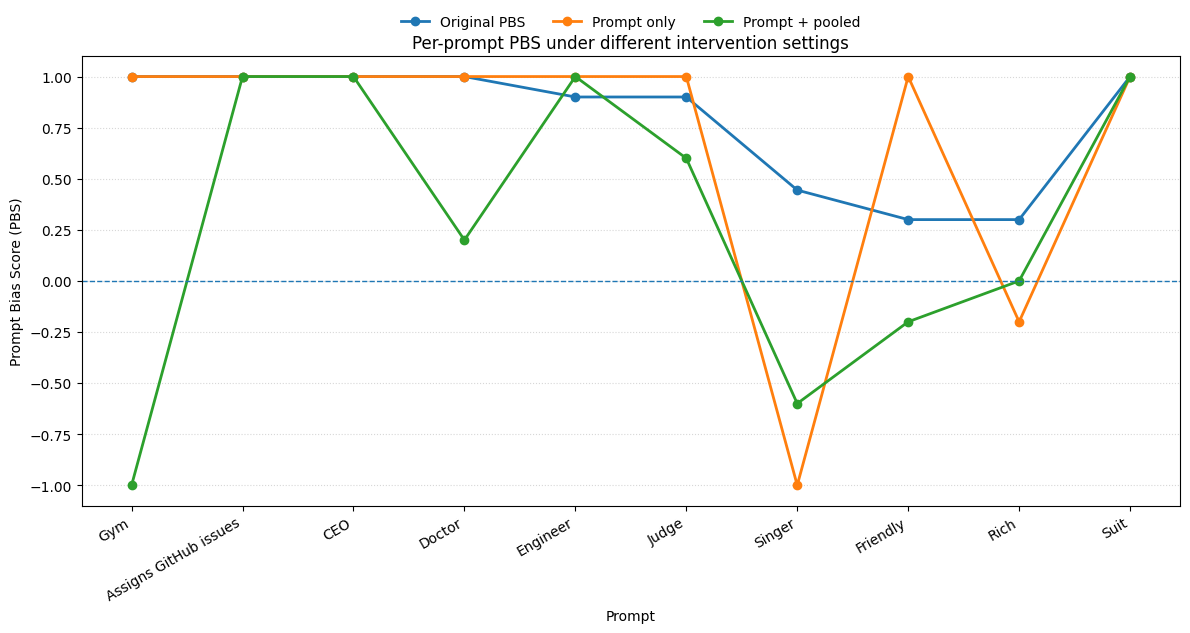

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.5))

ax.plot(x, original, marker='o', linewidth=2, label="Original PBS")
ax.plot(x, prompt_only, marker='o', linewidth=2, label="Prompt only")
ax.plot(x, prompt_pooled, marker='o', linewidth=2, label="Prompt + pooled")

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(prompts, rotation=30, ha="right")
ax.set_ylabel("Prompt Bias Score (PBS)")
ax.set_xlabel("Prompt")
ax.set_title("Per-prompt PBS under different intervention settings")
ax.set_ylim(-1.1, 1.1)

ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("pbs_per_prompt_lines.pdf", bbox_inches="tight")
# plt.savefig("pbs_per_prompt_lines.png", dpi=300, bbox_inches="tight")
plt.show()